<hr>
<h1><center>| Projet 4: Construisez un modèle de scoring |</center></h1>

<hr>
<h1><center>| Modélisation |</center></h1>

<br>
<br>

>__Réalisé par : Said Arrazouaki__

In [2]:
random_state = 123

In [3]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd

data = pd.read_pickle("./data_cleaned/data.pkl")

data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,ANNUITY_CREDIT_RATIO,bureau_active_loans_count_x,bureau_avg_days_overdue_x,bureau_active_loans_count_y,bureau_avg_days_overdue_y,installment_late_payment_percentage,credit_card_avg_usage,credit_card_avg_days_past_due,credit_card_avg_usage_missing,credit_card_avg_days_past_due_missing
0,100002.0,1,Cash loans,M,N,Y,0.0,202500.0,406597.5,24700.5,...,0.060749,2.0,0.0,2.0,0.0,0.000000,0.0,0.0,1,1
1,100003.0,0,Cash loans,F,N,N,0.0,270000.0,1293502.5,35698.5,...,0.027598,1.0,0.0,1.0,0.0,0.000000,0.0,0.0,1,1
2,100004.0,0,Revolving loans,M,Y,Y,0.0,67500.0,135000.0,6750.0,...,0.050000,2.0,0.0,2.0,0.0,0.000000,0.0,0.0,1,1
3,100006.0,0,Cash loans,F,N,Y,0.0,135000.0,312682.5,29686.5,...,0.094941,2.0,0.0,2.0,0.0,0.000000,0.0,0.0,0,0
4,100007.0,0,Cash loans,M,N,Y,0.0,121500.0,513000.0,21865.5,...,0.042623,2.0,0.0,2.0,0.0,0.242424,0.0,0.0,1,1


In [5]:
data.shape

(306856, 93)

In [7]:
data.TARGET.value_counts()

TARGET
0    282098
1     24758
Name: count, dtype: int64

In [8]:
data.dtypes.value_counts()

object     46
float64    45
int32       2
Name: count, dtype: int64

In [9]:
data_cat = data.select_dtypes(include=["object"])

In [10]:
data_cat.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
0,1,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,...,0,0,0,0,0,0,0,0,0,0
1,0,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,...,0,0,0,0,0,0,0,0,0,0
2,0,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,...,0,0,0,0,0,0,0,0,0,0
3,0,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,...,0,0,0,0,0,0,0,0,0,0
4,0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,...,0,0,0,0,0,0,0,0,0,0


In [11]:
cat_col = data_cat.columns

In [12]:
for col in cat_col:
    print(f"For {col} there is : {data[col].nunique()} unique values")

For TARGET there is : 2 unique values
For NAME_CONTRACT_TYPE there is : 2 unique values
For CODE_GENDER there is : 2 unique values
For FLAG_OWN_CAR there is : 2 unique values
For FLAG_OWN_REALTY there is : 2 unique values
For NAME_TYPE_SUITE there is : 7 unique values
For NAME_INCOME_TYPE there is : 8 unique values
For NAME_EDUCATION_TYPE there is : 5 unique values
For NAME_FAMILY_STATUS there is : 6 unique values
For NAME_HOUSING_TYPE there is : 6 unique values
For FLAG_MOBIL there is : 2 unique values
For FLAG_EMP_PHONE there is : 2 unique values
For FLAG_WORK_PHONE there is : 2 unique values
For FLAG_CONT_MOBILE there is : 2 unique values
For FLAG_PHONE there is : 2 unique values
For FLAG_EMAIL there is : 2 unique values
For OCCUPATION_TYPE there is : 18 unique values
For WEEKDAY_APPR_PROCESS_START there is : 7 unique values
For REG_REGION_NOT_LIVE_REGION there is : 2 unique values
For REG_REGION_NOT_WORK_REGION there is : 2 unique values
For LIVE_REGION_NOT_WORK_REGION there is : 2

In [18]:
data_cat['ORGANIZATION_TYPE'].value_counts()['XNA']/data_cat.shape[0]*100

18.00942461610658

In [15]:
data.isna().sum().sum()

0

## Evaluation du performance

#### Critères d'Évaluation des Modèles

- Performance, mesurée par : métrique personalisé , ROC AUC
- Vitesse d'exécution
- Interprétabilité


#### Métriques de Performance

**-Matrice de Confusion**

|               | Prédiction : 0 | Prédiction : 1 |
|---------------|-----------------|-----------------|
| **Réel : 0**  | True Negative (TN) | False Positive (FP) |
| **Réel : 1**  | False Negative (FN) | True Positive (TP) |


**-Accuracy** : Représente le pourcentage de bonnes prédictions faites par le modèle :
$$accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

**-Recall** : Indique le pourcentage de positifs correctement prédits :
$$recall = \frac{TP}{TP + FN}$$
Un recall élevé maximise le nombre de vrais positifs, mais n'indique pas la qualité des prédictions sur les négatifs.

**-Precision** : Mesure le nombre de prédictions positives correctes :
$$precision = \frac{TP}{TP + FP}$$
Une précision élevée signifie que la majorité des prédictions positives sont correctes, réduisant les faux positifs.

#### Courbe ROC et AUC

La courbe ROC montre le taux de vrais positifs (recall) en fonction du taux de faux positifs :
- **TPR** (taux de vrais positifs) : $$TPR = \frac{TP}{TP + FN}$$
- **FPR** (taux de faux positifs) : $$FPR = \frac{FP}{FP + TN}$$

L'AUC est l'aire sous la courbe ROC, mesurant la capacité du modèle à distinguer les classes :
- AUC = 1 : modèle parfait
- AUC = 0 : modèle totalement incorrect
L’AUC est indépendante des seuils de classification et de l’échelle.

**Note** : Dans notre cas, une étiquette de sortie "1" indique un défaut de paiement, et "0" une absence de défaut. Nous cherchons donc à privilégier des modèles qui minimisent les faux négatifs.

In [91]:
from sklearn.metrics import confusion_matrix


# Fonction personnalisée
def score_personnalise(y_true, y_pred):
    """
    Fonction calculant une métrique personnalisée pour évaluer les erreurs du modèle.

    Args:
    y_true : Les vraies étiquettes de classe.
    y_pred : Les prédictions du modèle.

    Returns:
    int : La valeur de la métrique personnalisée (10 * FN + FP).
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return -(10 * fn + fp)


In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Rapport de performance
def generate_model_report(model, X_test, y_test):
    """
    Fonction générant un rapport de performance pour un modèle de classification.

    Args:
    modele : Le modèle déjà entraîné.
    X_test : Ensemble de test des caractéristiques.
    y_test : Étiquettes de l'ensemble de test.

    Affiche les métriques dans la console.
    Génère également un graphique de matrice de confusion.
    """
    y_pred = model.predict(X_test)
    print("-----------------------------------------")
    print(f"Accuracy      = {round(accuracy_score(y_test, y_pred), 3)}")
    print(f"Precision     = {round(precision_score(y_test, y_pred), 3)}")
    print(f"Recall        = {round(recall_score(y_test, y_pred), 3)}")
    print(f"f1_score      = {round(f1_score(y_test, y_pred), 3)}")
    print(f"Custom metric = {- score_personnalise(y_test, y_pred)}")
    print("-----------------------------------------")

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    _ = plt.title("Matrice de confusion", fontsize=20)


In [93]:
from sklearn.metrics import roc_auc_score, roc_curve


#
def generate_roc_curve(model, X_test, y_test):
    """
    Fonction générant et affichant la courbe ROC pour un modèle de classification.

    Args:
    model : Le modèle de classification entraîné.
    X : Les caractéristiques de l'ensemble de données.
    y : Les vraies étiquettes de classe.

    Affiche la courbe ROC et les scores AUC pour le modèle et une baseline.
    """

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    ns_probs = [0 for i in range(len(y_test))]

    # Calcul des scores AUC
    ns_auc = roc_auc_score(y_test, ns_probs)
    auc = roc_auc_score(y_test, y_pred_proba)

    print(f"{type(model).__name__}      : ROC AUC=%.3f" % (auc))

    # Calcul des courbes ROC
    ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
    lr_fpr, lr_tpr, _ = roc_curve(y_test, y_pred_proba)

    # Tracer la courbe ROC
    if type(model).__name__ != "DummyClassifier":
        print("DummyClassifier      : ROC AUC=%.3f" % (ns_auc))
        plt.plot(
            ns_fpr,
            ns_tpr,
            linestyle="--",
            label=f"DummyClassifier (AUC = {ns_auc})",
            lw=1.5,
        )
    plt.plot(
        lr_fpr,
        lr_tpr,
        label=f"{type(model).__name__} (AUC = {auc:.3f})",
        marker="+",
        lw=2,
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(bbox_to_anchor=(1.05, 0.95), loc="upper left")
    plt.title("Receiver Operating Characteristic curve", fontsize=20)
    plt.show()


## Modélisation

In [94]:
X = data.drop(columns=["TARGET", "SK_ID_CURR"])
y = data["TARGET"].astype(int)

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=random_state
)

### Modèle de référence: DummyClassifier

Nous utiliserons comme modèle de référence le `DummyClassifier` de `scikit-learn` qui fait des prédictions aléatoires avec le paramètre `strategy="constant` :

In [96]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="constant", constant=0)

dummy.fit(X_train, y_train)


DummyClassifier(constant=0, strategy='constant')

In [97]:
type(dummy).__name__


'DummyClassifier'

-----------------------------------------
Accuracy      = 0.921
Precision     = 0.0
Recall        = 0.0
f1_score      = 0.0
Custom metric = 60340
-----------------------------------------


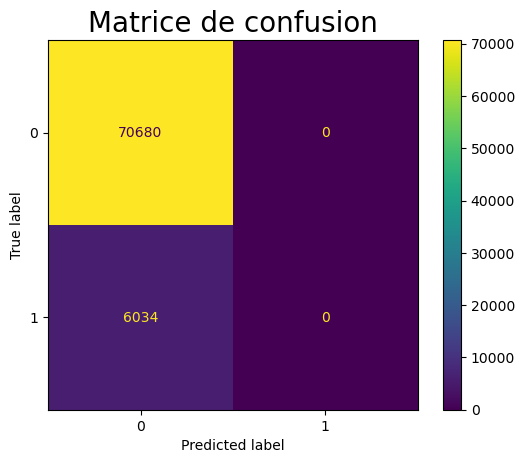

In [98]:
generate_model_report(dummy, X_test, y_test)

DummyClassifier      : ROC AUC=0.500


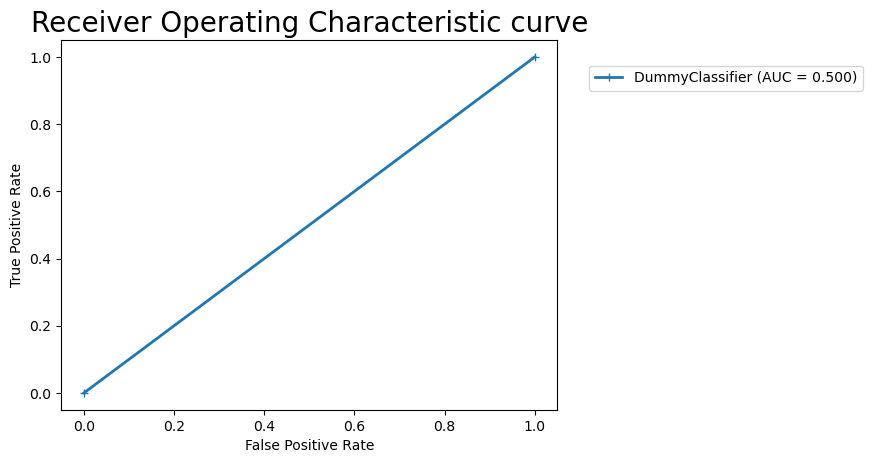

In [99]:
generate_roc_curve(dummy, X_test, y_test)

### Régression logistique

In [100]:
categorical_features = X.select_dtypes(include="object").columns.to_list()
numerical_features = X.select_dtypes(exclude="object").columns.to_list()

In [101]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_preprocessor = OneHotEncoder(handle_unknown="ignore", drop="first")

numerical_preprocessor = StandardScaler()

preprocessor_linear = ColumnTransformer(
    [
        ("cat_preprocessor", categorical_preprocessor, categorical_features),
        ("num_preprocessor", numerical_preprocessor, numerical_features),
    ]
)

In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

linear_model = Pipeline(
    [
        ("preprocessor", preprocessor_linear),
        (
            "classifier",
            LogisticRegression(C=1, class_weight="balanced"),
        ),
    ]
)


In [103]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat_preprocessor',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['NAME_CONTRACT_TYPE',
                                                   'CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'FLAG_MOBIL',
                                                   'FLAG_EMP_PHONE',
                                                   'FLAG_WORK_PHON...
                                                   'YEARS_BEGINEXPLUATATION_MODE',
                                                   'FLOORSMAX_MODE',
                                                   'YEARS_BEGINEXPLUATATION_MEDI',
                                                   'FLOORSMAX_MEDI',
                                                   'TOTALAREA_MODE',
                                                   'OBS_30_CNT_SOCIAL_CIRCLE',
                                                   'DEF_30_CNT_SOCIAL_CIRCLE',
                                                   'OBS_60_CNT_SOCIAL_CIRCLE',
                                                   'DEF_60_CNT_SOCIAL_CIRCLE',
                                                   'DAYS_LAST_PHONE_CHANGE',
                                                   'AMT_REQ_CREDIT_BUREAU_HOUR',
                                                   'AMT_REQ_CREDIT_BUREAU_DAY', ...])])),
                ('classifier',
                 LogisticRegression(C=1, class_weight='balanced'))])

-----------------------------------------
Accuracy      = 0.695
Precision     = 0.161
Recall        = 0.68
f1_score      = 0.26
Custom metric = 40754
-----------------------------------------


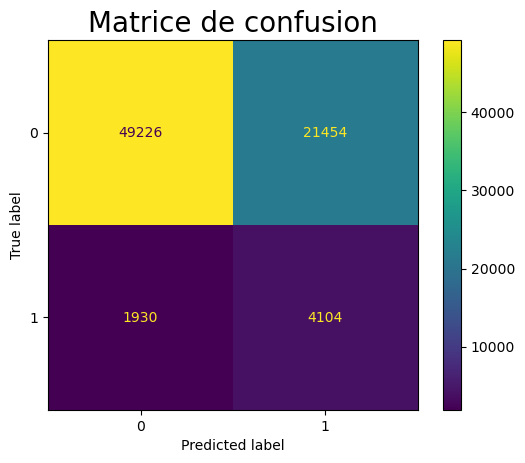

In [104]:
generate_model_report(linear_model, X_test, y_test)

Pipeline      : ROC AUC=0.754
DummyClassifier      : ROC AUC=0.500


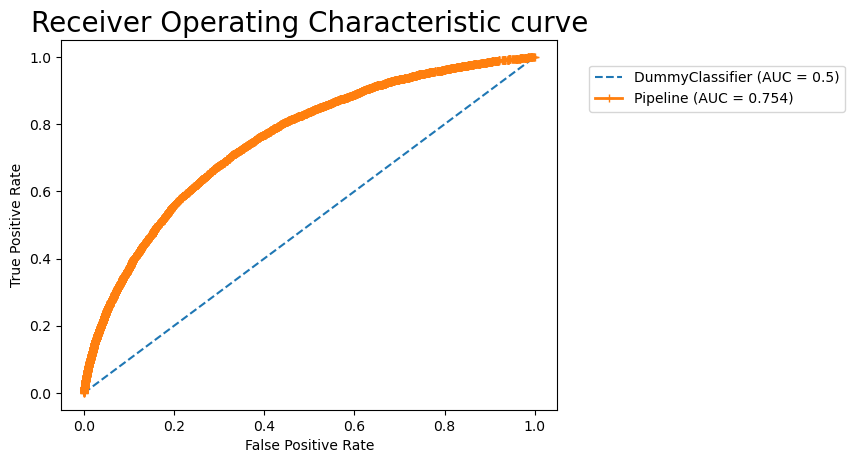

In [105]:
generate_roc_curve(linear_model, X_test, y_test)

### Les arbres de decisions

In [106]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder

categorical_preprocessor = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1
)

preprocessor = ColumnTransformer(
    [("cat_preprocessor", categorical_preprocessor, categorical_features)],
    remainder="passthrough",
)

tree_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(class_weight="balanced", max_depth=5),
        ),
    ]
)

In [107]:
tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_preprocessor',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['NAME_CONTRACT_TYPE',
                                                   'CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'FLAG...
                                                   'REG_REGION_NOT_WORK_REGION',
                                                   'LIVE_REGION_NOT_WORK_REGION',
                                                   'REG_CITY_NOT_LIVE_CITY',
                                                   'REG_CITY_NOT_WORK_CITY',
                                                   'LIVE_CITY_NOT_WORK_CITY',
                                                   'ORGANIZATION_TYPE',
                                                   'EMERGENCYSTATE_MODE',
                                                   'FLAG_DOCUMENT_2',
                                                   'FLAG_DOCUMENT_3',
                                                   'FLAG_DOCUMENT_4',
                                                   'FLAG_DOCUMENT_5',
                                                   'FLAG_DOCUMENT_6', ...])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5))])

-----------------------------------------
Accuracy      = 0.691
Precision     = 0.146
Recall        = 0.606
f1_score      = 0.236
Custom metric = 45089
-----------------------------------------


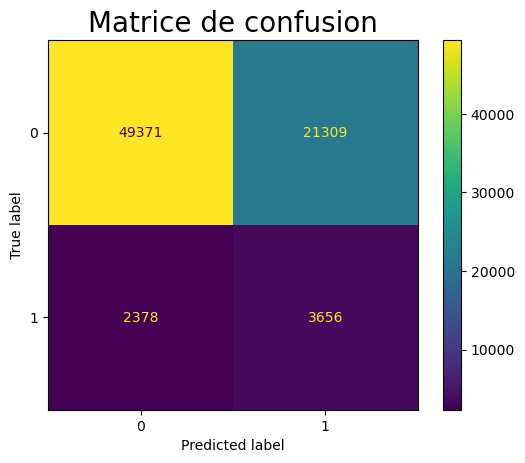

In [108]:
generate_model_report(tree_model, X_test, y_test)

Pipeline      : ROC AUC=0.707
DummyClassifier      : ROC AUC=0.500


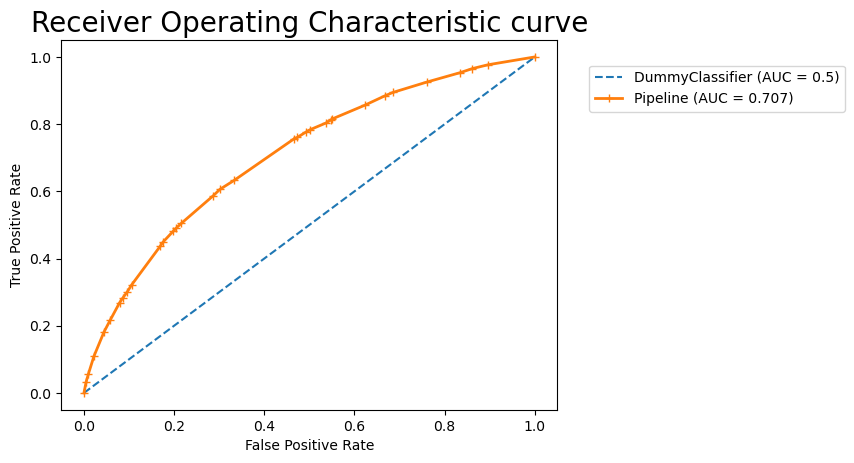

In [109]:
generate_roc_curve(tree_model, X_test, y_test)

### Random forest

In [110]:
from sklearn.ensemble import RandomForestClassifier


random_forest_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                class_weight="balanced",
                max_depth=5,
                n_estimators=500,
                random_state=random_state,
            ),
        ),
    ]
)

In [111]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_preprocessor',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['NAME_CONTRACT_TYPE',
                                                   'CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'FLAG...
                                                   'LIVE_REGION_NOT_WORK_REGION',
                                                   'REG_CITY_NOT_LIVE_CITY',
                                                   'REG_CITY_NOT_WORK_CITY',
                                                   'LIVE_CITY_NOT_WORK_CITY',
                                                   'ORGANIZATION_TYPE',
                                                   'EMERGENCYSTATE_MODE',
                                                   'FLAG_DOCUMENT_2',
                                                   'FLAG_DOCUMENT_3',
                                                   'FLAG_DOCUMENT_4',
                                                   'FLAG_DOCUMENT_5',
                                                   'FLAG_DOCUMENT_6', ...])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        n_estimators=500, random_state=123))])

-----------------------------------------
Accuracy      = 0.682
Precision     = 0.153
Recall        = 0.669
f1_score      = 0.248
Custom metric = 42405
-----------------------------------------


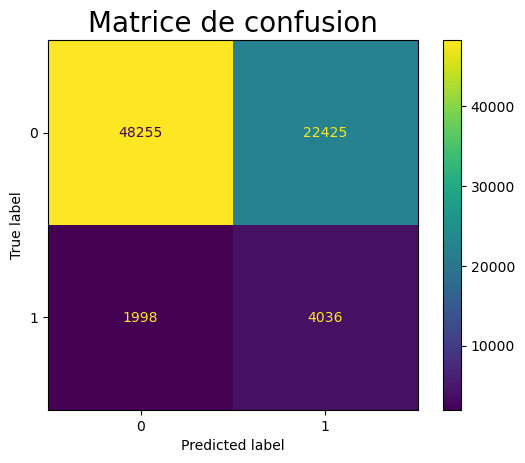

In [112]:
generate_model_report(random_forest_model, X_test, y_test)

Pipeline      : ROC AUC=0.735
DummyClassifier      : ROC AUC=0.500


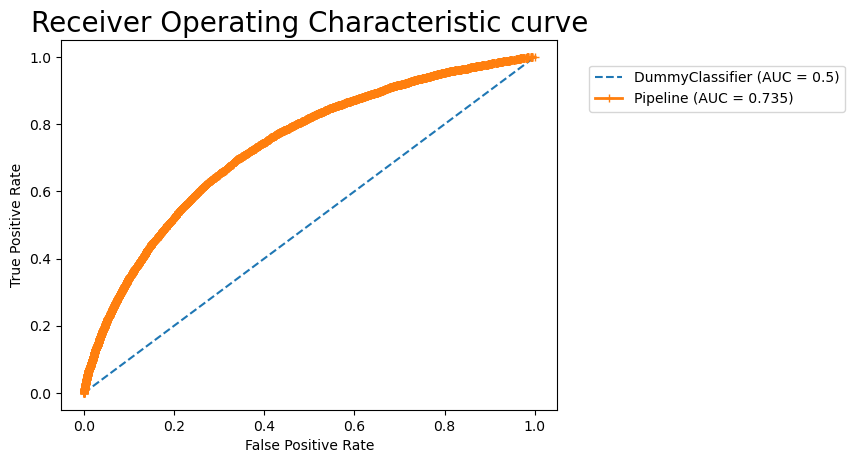

In [113]:
generate_roc_curve(random_forest_model, X_test, y_test)

### Histogram gradiend boosting classifier

In [114]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgbc_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            HistGradientBoostingClassifier(
                random_state=42, max_leaf_nodes=4, class_weight="balanced"
            ),
        ),
    ]
)
hgbc_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_preprocessor',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['NAME_CONTRACT_TYPE',
                                                   'CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'FLAG...
                                                   'LIVE_REGION_NOT_WORK_REGION',
                                                   'REG_CITY_NOT_LIVE_CITY',
                                                   'REG_CITY_NOT_WORK_CITY',
                                                   'LIVE_CITY_NOT_WORK_CITY',
                                                   'ORGANIZATION_TYPE',
                                                   'EMERGENCYSTATE_MODE',
                                                   'FLAG_DOCUMENT_2',
                                                   'FLAG_DOCUMENT_3',
                                                   'FLAG_DOCUMENT_4',
                                                   'FLAG_DOCUMENT_5',
                                                   'FLAG_DOCUMENT_6', ...])])),
                ('classifier',
                 HistGradientBoostingClassifier(class_weight='balanced',
                                                max_leaf_nodes=4,
                                                random_state=42))])

-----------------------------------------
Accuracy      = 0.698
Precision     = 0.162
Recall        = 0.679
f1_score      = 0.261
Custom metric = 40629
-----------------------------------------


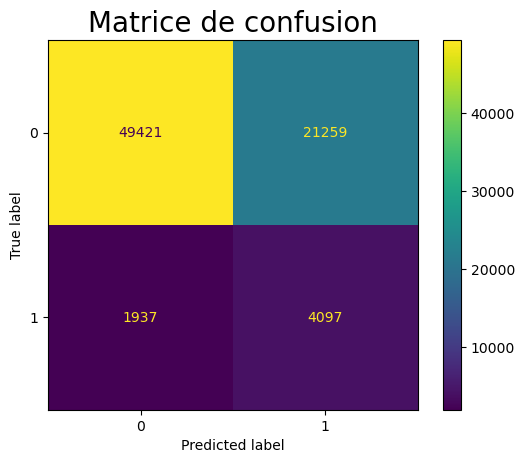

In [115]:
generate_model_report(hgbc_model, X_test, y_test)

Pipeline      : ROC AUC=0.753
DummyClassifier      : ROC AUC=0.500


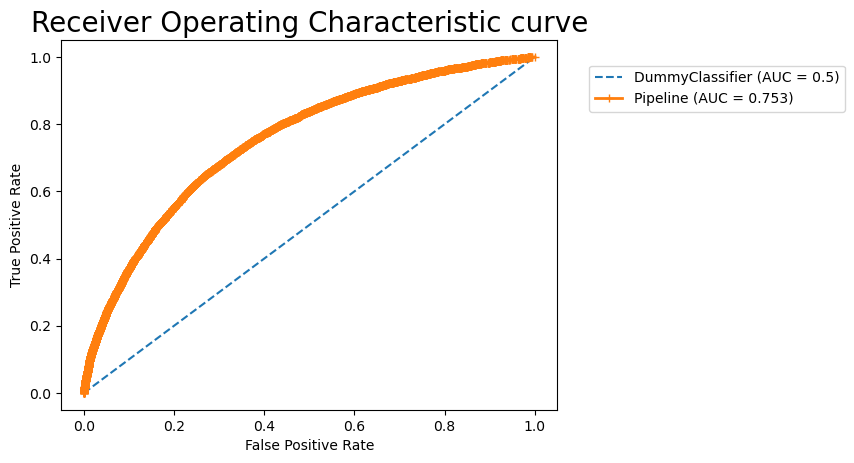

In [116]:
generate_roc_curve(hgbc_model, X_test, y_test)

### XGboost

In [120]:
from xgboost import XGBClassifier

# Compute scale_pos_weight as the ratio of the majority class to the minority class
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                random_state=42,
                max_depth=2,
                n_estimators=500,
                scale_pos_weight=scale_pos_weight,
            ),
        ),
    ]
)
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_preprocessor',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['NAME_CONTRACT_TYPE',
                                                   'CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'FLAG...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

-----------------------------------------
Accuracy      = 0.716
Precision     = 0.172
Recall        = 0.683
f1_score      = 0.274
Custom metric = 39020
-----------------------------------------


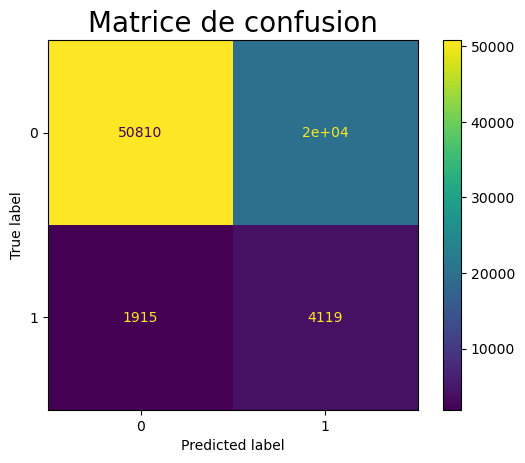

In [121]:
generate_model_report(xgb_model, X_test, y_test)

Pipeline      : ROC AUC=0.766
DummyClassifier      : ROC AUC=0.500


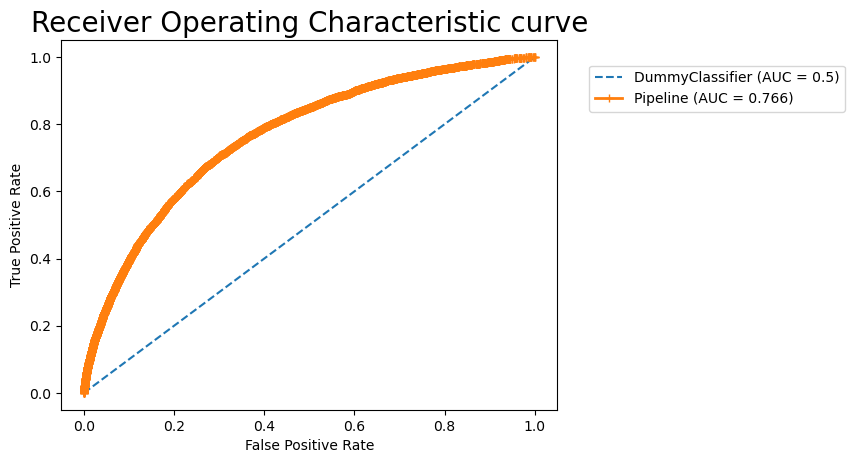

In [122]:
generate_roc_curve(xgb_model, X_test, y_test)

### LightGBM

In [123]:
from lightgbm import LGBMClassifier

# Compute scale_pos_weight as the ratio of the majority class to the minority class
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

lgbm_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            LGBMClassifier(
                random_state=random_state,
                max_depth=10,
                n_estimators=1000,
                learning_rate=0.02,
                scale_pos_weight=scale_pos_weight,
            ),
        ),
    ]
)
lgbm_model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 18724, number of negative: 211418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028490 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6292
[LightGBM] [Info] Number of data points in the train set: 230142, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081358 -> initscore=-2.424031
[LightGBM] [Info] Start training from score -2.424031


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_preprocessor',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['NAME_CONTRACT_TYPE',
                                                   'CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'FLAG...
                                                   'REG_CITY_NOT_LIVE_CITY',
                                                   'REG_CITY_NOT_WORK_CITY',
                                                   'LIVE_CITY_NOT_WORK_CITY',
                                                   'ORGANIZATION_TYPE',
                                                   'EMERGENCYSTATE_MODE',
                                                   'FLAG_DOCUMENT_2',
                                                   'FLAG_DOCUMENT_3',
                                                   'FLAG_DOCUMENT_4',
                                                   'FLAG_DOCUMENT_5',
                                                   'FLAG_DOCUMENT_6', ...])])),
                ('classifier',
                 LGBMClassifier(learning_rate=0.02, max_depth=10,
                                n_estimators=1000, random_state=123,
                                scale_pos_weight=11.291283913693656))])

-----------------------------------------
Accuracy      = 0.723
Precision     = 0.173
Recall        = 0.67
f1_score      = 0.275
Custom metric = 39206
-----------------------------------------


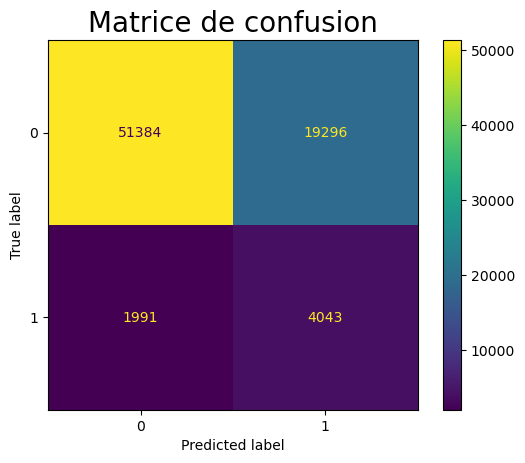

In [124]:
generate_model_report(lgbm_model, X_test, y_test)

Pipeline      : ROC AUC=0.766
DummyClassifier      : ROC AUC=0.500


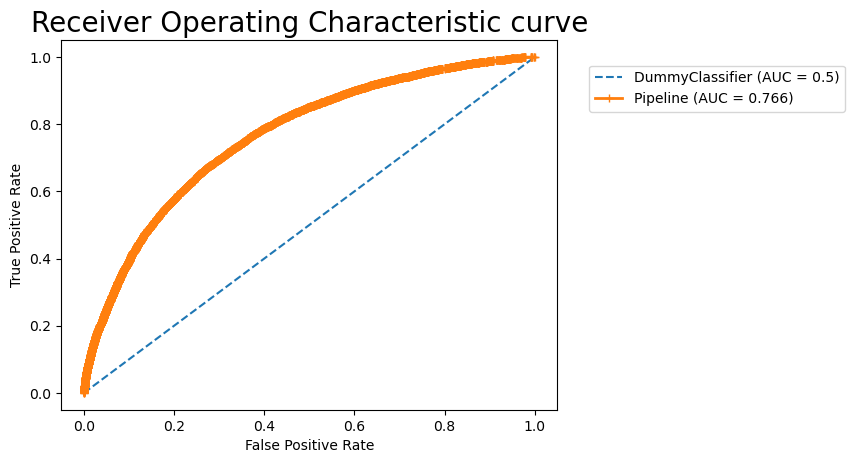

In [125]:
generate_roc_curve(lgbm_model, X_test, y_test)